<a href="https://colab.research.google.com/github/adrianfelsky/TrabalhoRedesNeurais26-2/blob/prep_end/Trabalho_Redes_Neurais_(Adrian_e_Yan).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##UFSC - Campus Blumenau
##Disciplina: CAC8002 - Inteligência Artificial

Alunos:

Adrian Gazzani Felsky dos Anjos\
Yan Claus Fructuoso

# Carregar os datasets no Colab

In [1]:
!git clone https://github.com/adrianfelsky/TrabalhoRedesNeurais26-2
!mv ./TrabalhoRedesNeurais26-2/ datasets

Cloning into 'TrabalhoRedesNeurais26-2'...
remote: Enumerating objects: 1254, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (28/28), done.
remote: Total 1254 (delta 13), reused 7 (delta 2), pack-reused 1224 (from 2)
Receiving objects: 100% (1254/1254), 89.88 MiB | 60.43 MiB/s, done.
Resolving deltas: 100% (16/16), done.


# Exercício 1

--- RESULTADO DA REDE NEURAL ---
Taxa de Acerto (Accuracy): 97.85%



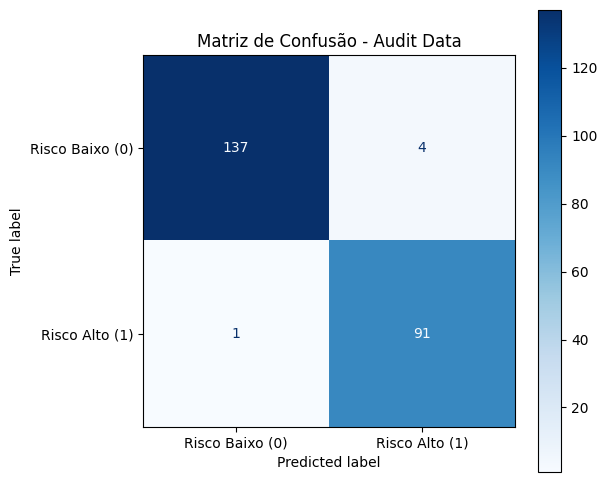

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

df = pd.read_csv('datasets/exercicio1/audit_data/audit_risk.csv')

# A coluna LOCATION_ID tem alguns valores em texto (ex: 'LOHAT'). Vamos forçar conversão para número e tratar nulos.
df['LOCATION_ID'] = pd.to_numeric(df['LOCATION_ID'], errors='coerce')

# Preencher possíveis valores vazios (NaN) com a mediana da coluna
df = df.fillna(df.median())

# O objetivo (target) no Audit Data é a coluna 'Risk'
X = df.drop(['Risk'], axis=1) # Características (Features)
y = df['Risk']                # Classe que queremos prever

# Separar instâncias de treinamento e teste (70% treino, 30% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Normalizar os dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Definir e treinar a Rede Neural Simples
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
mlp.fit(X_train_scaled, y_train)

# Avaliação do Modelo
y_pred = mlp.predict(X_test_scaled)
acuracia = accuracy_score(y_test, y_pred)

print(f"--- RESULTADO DA REDE NEURAL ---")
print(f"Taxa de Acerto (Accuracy): {acuracia * 100:.2f}%\n")

# Apresentar a Matriz de Confusão
matriz = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=["Risco Baixo (0)", "Risco Alto (1)"])

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title("Matriz de Confusão - Audit Data")
plt.show()

# Comparação com o WEKA



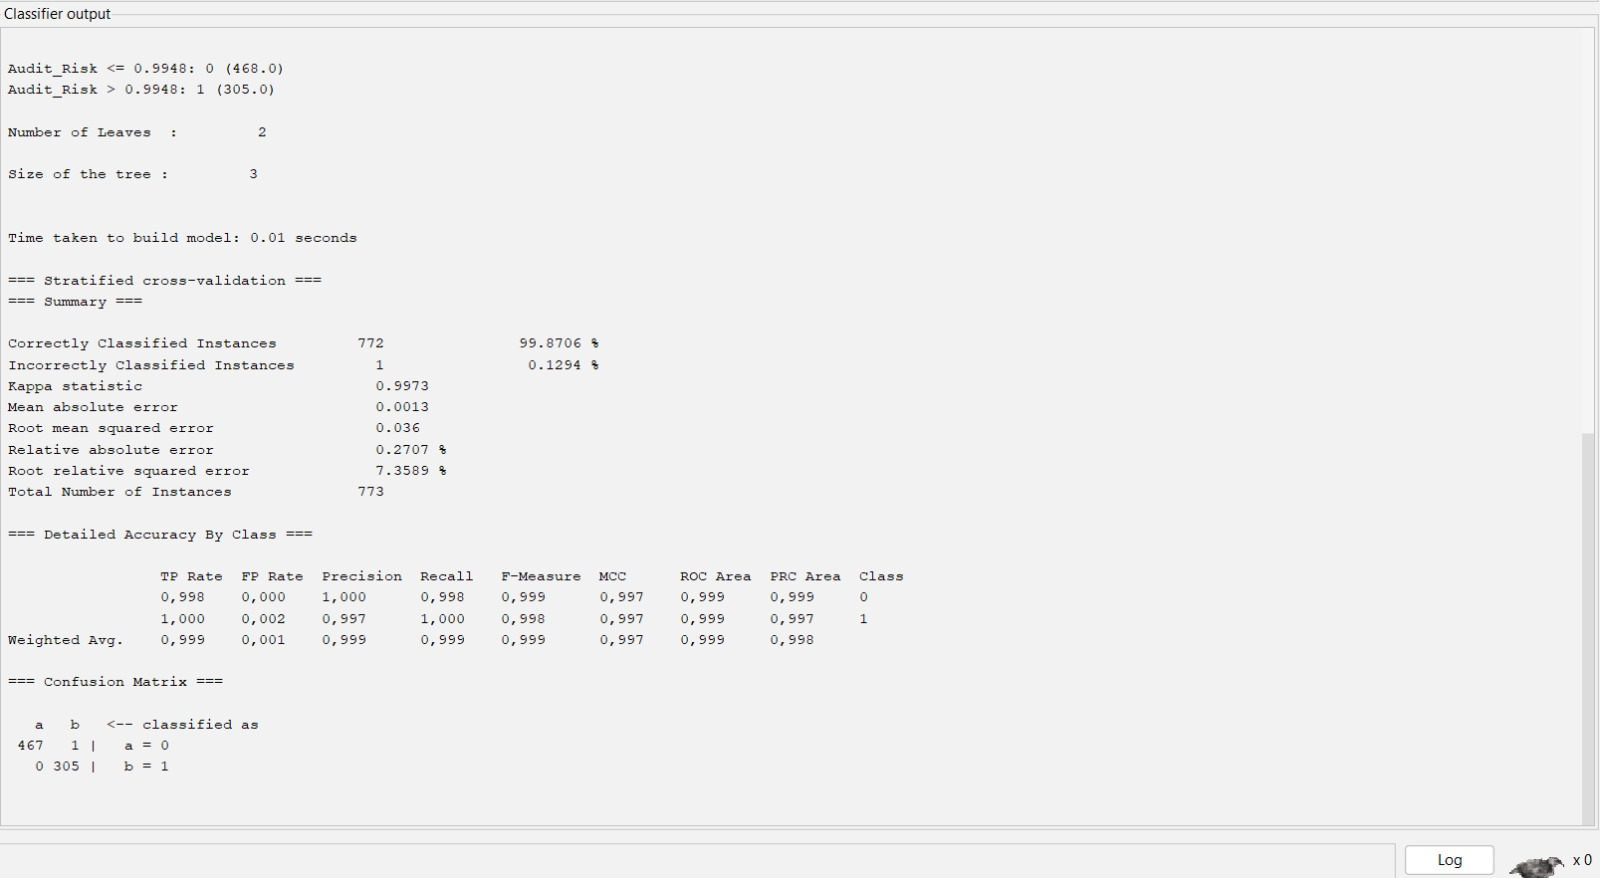

A Rede Neural Simples (MLP) obteve 97.85% de acurácia, enquanto a Árvore de Decisão J48 obteve 99.87%. Observa-se que o modelo X teve um desempenho melhor/pior para classificar as instâncias de risco.

# Exercício 2

Found 960 files belonging to 2 classes.
Found 240 files belonging to 2 classes.
Classes carregadas: ['aviao', 'barco']
Epoch 1/25


/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.5500 - loss: 0.8706 - val_accuracy: 0.6375 - val_loss: 0.6430
Epoch 2/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6781 - loss: 0.6122 - val_accuracy: 0.7500 - val_loss: 0.5700
Epoch 3/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.7031 - loss: 0.5710 - val_accuracy: 0.7875 - val_loss: 0.4691
Epoch 4/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 35s 1s/step - accuracy: 0.7573 - loss: 0.4808 - val_accuracy: 0.8500 - val_loss: 0.3762
Epoch 5/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.7802 - loss: 0.4490 - val_accuracy: 0.8375 - val_loss: 0.3574
Epoch 6/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.8229 - loss: 0.4016 - val_accuracy: 0.8708 - val_loss: 0.3639
Epoch 7/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.8354 - loss: 0.3837 - val_accuracy: 0.8042 - val_loss: 0.6177
Epoch 8/25
30/30 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8260 - loss: 0.3940 - val_accuracy: 0.8458 - val_loss: 0.3414
Epo

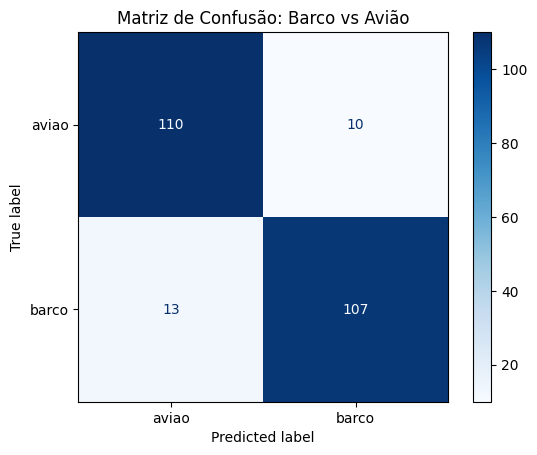

In [3]:
# Importar bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Configurar os caminhos e carregar as imagens
caminho_treino = '/content/datasets/exercicio2/dataset/treino'
caminho_teste = '/content/datasets/exercicio2/dataset/teste'

tamanho_lote = 32
altura_img = 150
largura_img = 150

# Carregar os datasets
dataset_treino = tf.keras.utils.image_dataset_from_directory(
  caminho_treino,
  image_size=(altura_img, largura_img),
  batch_size=tamanho_lote)

dataset_teste = tf.keras.utils.image_dataset_from_directory(
  caminho_teste,
  image_size=(altura_img, largura_img),
  batch_size=tamanho_lote)

nomes_classes = dataset_treino.class_names
print(f"Classes carregadas: {nomes_classes}")

# Otimização de performance no carregamento
AUTOTUNE = tf.data.AUTOTUNE
dataset_treino = dataset_treino.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
dataset_teste = dataset_teste.cache().prefetch(buffer_size=AUTOTUNE)

# Construir a Rede Neural Convolucional (CNN)
# Incluindo camadas de Data Augmentation para ajudar a atingir a meta de >90% de acurácia
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal", input_shape=(altura_img, largura_img, 3)),
  layers.RandomRotation(0.1),
  layers.RandomZoom(0.1),
])

modelo = models.Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dropout(0.5),
  layers.Dense(len(nomes_classes), activation='softmax')
])

modelo.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

# Treinar a Rede com Early Stopping
epocas = 25

historico = modelo.fit(
  dataset_treino,
  validation_data=dataset_teste,
  epochs=epocas
)

# Avaliar o modelo e apresentar a Acurácia
perda, acuracia = modelo.evaluate(dataset_teste)
print(f"\n--- RESULTADO FINAL ---")
print(f"Acurácia no Dataset de Teste: {acuracia * 100:.2f}%")

# Gerar a Matriz de Confusão
y_verdadeiro = []
y_previsto = []

# Iterar sobre o dataset de teste para pegar as previsões
for imagens, rotulos in dataset_teste:
    y_verdadeiro.extend(rotulos.numpy())
    previsoes = modelo.predict(imagens, verbose=0)
    y_previsto.extend(np.argmax(previsoes, axis=-1))

matriz = confusion_matrix(y_verdadeiro, y_previsto)

# Plotar a Matriz
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=nomes_classes)
disp.plot(cmap='Blues')
plt.title("Matriz de Confusão: Barco vs Avião")
plt.show()